# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Fawwaz Abhitah Sugiarto 
**NIM:** 122140014

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

In [13]:
# Import Library yang dipakai
import numpy as np 
import matplotlib.pyplot as plt 
import cv2 
import os 
import urllib.request
import dlib

# Cek versi library
print(f"Versi numpy: {np.__version__}")
print(f"Versi matplotlib: {plt.matplotlib.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")
print(f"Versi dlib: {dlib.__version__}")

Versi numpy: 2.2.6
Versi matplotlib: 3.10.7
Versi OpenCV: 4.12.0
Versi dlib: 19.24.6


### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.

#### **Soal 1 — Langkah-Langkah Jawaban**
1. Menulis kode untuk memuat gambar dan informasi dasar.

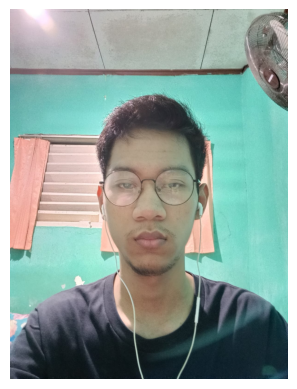

Ukuran gambar dan channel: (1599, 1200, 3)


In [20]:
# Path Gambar
path_gambar = os.path.join(os.getcwd(), "assets_ws4", "selfie.jpg")

# Membaca gambar
gambar = cv2.imread(path_gambar)

if gambar is None:
    print("Gambar tidak ditemukan!")
else:
    # Konversi BGR ke RGB untuk matplotlib
    gambar_rgb = cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB)

    # Tampilkan gambar
    plt.imshow(gambar_rgb)
    plt.axis("off")
    plt.show()

    print("Ukuran gambar dan channel:", gambar.shape)

2. Melakukan pemotongan (cropping) gambar pada area wajah dan latar belakang.

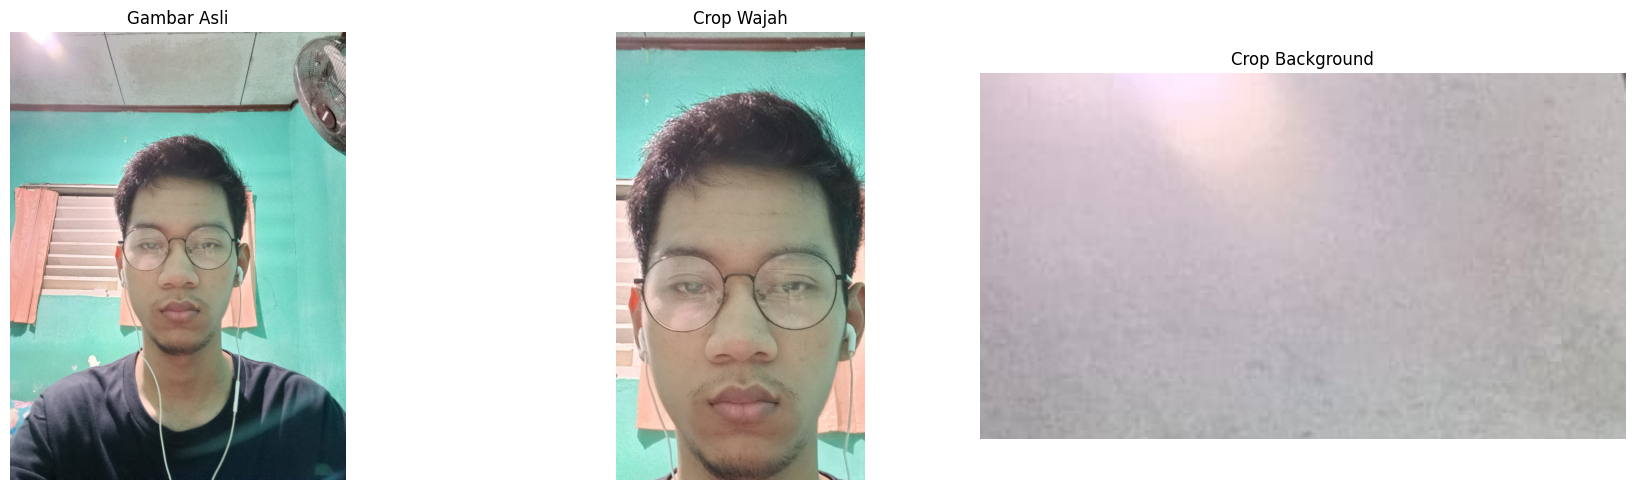

In [70]:
path_gambar = os.path.join(os.getcwd(), "assets_ws4", "selfie.jpg")
img = cv2.imread(path_gambar)

# Pastikan gambar terbaca
if img is None:
    print("Gambar tidak ditemukan.")
else:
    # Konversi BGR -> RGB 
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Pemotongan (cropping)
    face_crop = img_rgb[250:1150, 350:850]
    bg_crop = img_rgb[50:220, 50:350]
    
    # Tampilkan hasil cropping
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Gambar Asli")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(face_crop)
    plt.title("Crop Wajah")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(bg_crop)
    plt.title("Crop Background")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Menyimpan hasil cropping
    save_dir = os.path.join("results_ws4")
    os.makedirs(save_dir, exist_ok=True)
    cv2.imwrite(os.path.join(save_dir, "Soal1_crop_face.jpg"), cv2.cvtColor(face_crop, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(save_dir, "Soal1_crop_background.jpg"), cv2.cvtColor(bg_crop, cv2.COLOR_RGB2BGR))

3. Melakukan resize hasil cropping menjadi 920x920 piksel.


Informasi Ukuran Sebelum Resize
Face crop: (900, 500, 3)
Background crop: (170, 300, 3)

Informasi Ukuran Setelah Resize 920x920
Face resized: (920, 920, 3)
Background resized: (920, 920, 3)


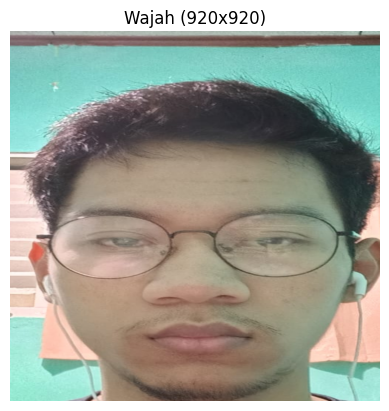

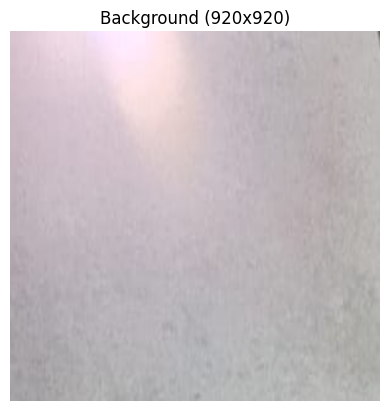

True

In [38]:
# Melakukan perubahan ukuran (resize) untuk kedua hasil cropping
resized_face = cv2.resize(face_crop, (920, 920))
resized_bg = cv2.resize(bg_crop, (920, 920))

# --- Informasi ukuran ---
print("\nInformasi Ukuran Sebelum Resize")
print("Face crop:", face_crop.shape)
print("Background crop:", bg_crop.shape)

print("\nInformasi Ukuran Setelah Resize 920x920")
print("Face resized:", resized_face.shape)
print("Background resized:", resized_bg.shape)

# --- Menampilkan hasil resize (tanpa dibandingkan berdampingan) ---
plt.imshow(resized_face)
plt.title("Wajah (920x920)")
plt.axis("off")
plt.show()

plt.imshow(resized_bg)
plt.title("Background (920x920)")
plt.axis("off")
plt.show()

# --- Menyimpan hasil resize ---
hasil_folder = os.path.join("results_ws4")
os.makedirs(hasil_folder, exist_ok=True)

path_face_resized = os.path.join(hasil_folder, "Soal1_Face_Resize_920.jpg")
path_bg_resized = os.path.join(hasil_folder, "Soal1_Background_Resize_920.jpg")

cv2.imwrite(path_face_resized, cv2.cvtColor(resized_face, cv2.COLOR_RGB2BGR))
cv2.imwrite(path_bg_resized, cv2.cvtColor(resized_bg, cv2.COLOR_RGB2BGR))


4. Melakukan konversi warna grayscale dan HSV pada gambar selfie.

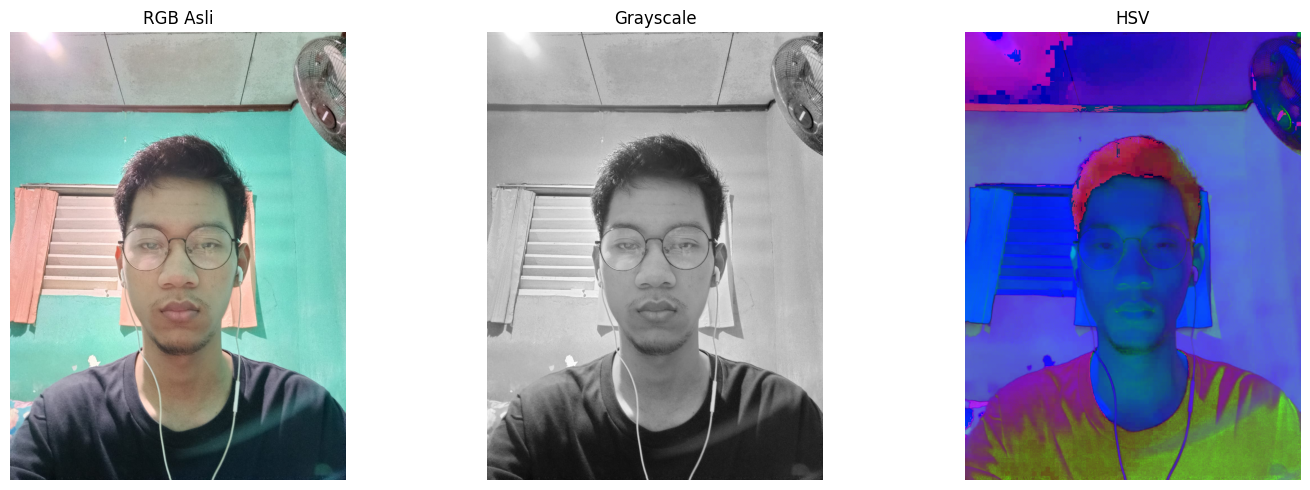

True

In [43]:
# Konversi ke Grayscale dan HSV
rgb_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
hsv_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# --- Tampilkan hasil ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("RGB Asli")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hsv_img)
plt.title("HSV")
plt.axis("off")

plt.tight_layout()
plt.show()

# Menyimpan hasil
hasil_folder = "results_ws4"
os.makedirs(hasil_folder, exist_ok=True)

cv2.imwrite(os.path.join(hasil_folder, "Soal1_Grayscale.jpg"), gray_img)
cv2.imwrite(os.path.join(hasil_folder, "Soal1_HSV.jpg"), hsv_img)


5. Tambahkan anotasi teks berisi nama di atas kepala pada gambar hasil crop.

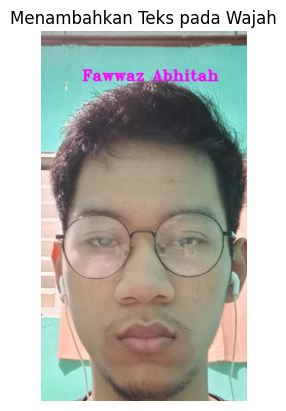

True

In [61]:
annotated_face = face_crop.copy()

# Mengatur posisi teks
posisi_teks = (100, 120)

# Menambahkan teks ke gambar
cv2.putText(annotated_face,"Fawwaz Abhitah", posisi_teks, cv2.FONT_HERSHEY_TRIPLEX, 1.2, (255, 0, 255), 2, cv2.LINE_AA)

# Menampilkan hasilnya
plt.imshow(annotated_face)
plt.title("Menambahkan Teks pada Wajah")
plt.axis("off")
plt.show()

# Menyimpan hasil anotasi
cv2.imwrite(
    os.path.join("results_ws4", "Soal1_Crop_Face_Annotated.jpg"),
    cv2.cvtColor(annotated_face, cv2.COLOR_RGB2BGR)
)


#### **Menjelaskan efek cropping dan perubahan warna**
1. **Efek Cropping**

    Cropping merupakan proses memotong sebuah bagian tertentu pada gambar untuk menghasilkan potongan gambar yang diinginkan. sebagai contoh pada percobaan yang dilakukan melakukan cropping agar gambar yang fokus pada wajah saja dan membuang bagian yang tidak diperlukan. Pada code face_crop = img_rgb[250:1150, 350:850] mengambil bagian gambar dari koordinat y=250 sampai y=1150 dan x=350 sampai x=850.

2. **Efek Perubahan Warna**

    Perubah warna yang dilakukan pada percobaan ini adalah mengubah sebuah gambar asli dengan menggunakan format RGB menjadi format Grayscale yang membuat gambar menjadi hitam putih dan format HSV yang membuat gambar menjadi lebih cerah dan kontras. 


### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


#### **Soal 2 — Langkah-Langkah Jawaban**
1. Melakukan manipulasi channel warna gambar.

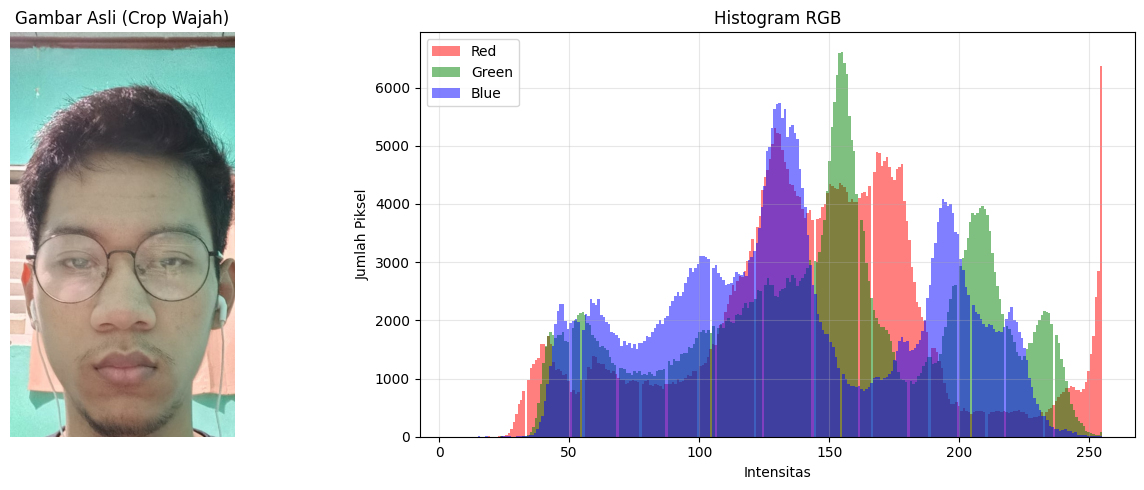

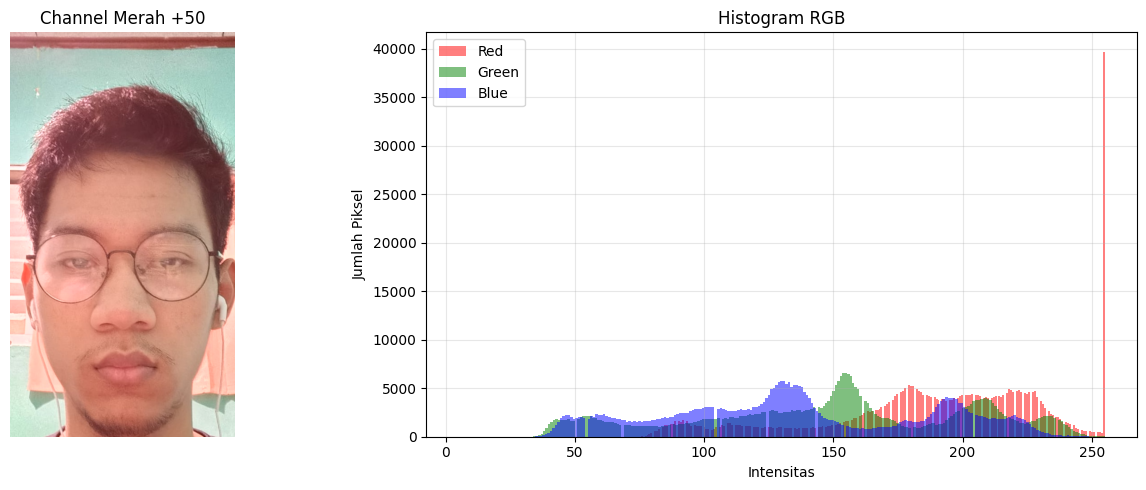

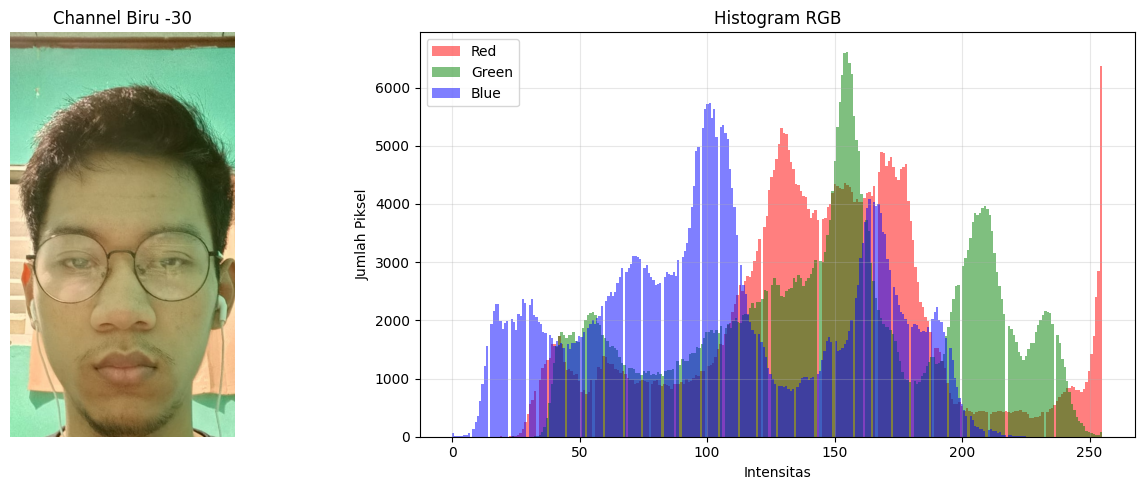

True

In [71]:
path_gambar = os.path.join(os.getcwd(), "results_ws4", "Soal1_crop_face.jpg")

img = cv2.imread(path_gambar)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def tampilkan(img_rgb, judul):
    plt.figure(figsize=(14,5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(judul)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.hist(img_rgb[:,:,0].flatten(), bins=255, color="red", alpha=0.5, label="Red")
    plt.hist(img_rgb[:,:,1].flatten(), bins=255, color="green", alpha=0.5, label="Green")
    plt.hist(img_rgb[:,:,2].flatten(), bins=255, color="blue", alpha=0.5, label="Blue")
    plt.title("Histogram RGB")
    plt.xlabel("Intensitas")
    plt.ylabel("Jumlah Piksel")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

tampilkan(rgb, "Gambar Asli (Crop Wajah)")

merah_plus = rgb.astype(np.int32)
merah_plus[:,:,0] = np.clip(merah_plus[:,:,0] + 50, 0, 255)
merah_plus = merah_plus.astype(np.uint8)
tampilkan(merah_plus, "Channel Merah +50")

biru_minus = rgb.astype(np.int32)
biru_minus[:,:,2] = np.clip(biru_minus[:,:,2] - 30, 0, 255)
biru_minus = biru_minus.astype(np.uint8)
tampilkan(biru_minus, "Channel Biru -30")

output_dir = os.path.join(os.getcwd(), "results_ws4")
cv2.imwrite(os.path.join(output_dir, "Soal2_RedPlus50.png"), cv2.cvtColor(merah_plus, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(output_dir, "Soal2_BlueMinus30.png"), cv2.cvtColor(biru_minus, cv2.COLOR_RGB2BGR))


2. Melakukan manipulasi channel warna gambar.

In [75]:
# Path gambar asli (crop face)
path_gambar = os.path.join(os.getcwd(), "results_ws4", "Soal1_crop_face.jpg")

img = cv2.imread(path_gambar)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Modifikasi channel merah +50
red_mod = np.clip(rgb[:,:,0].astype(np.int32) + 50, 0, 255).astype(np.uint8)

# Modifikasi channel biru -30
blue_mod = np.clip(rgb[:,:,2].astype(np.int32) - 30, 0, 255).astype(np.uint8)

# Channel hijau tetap
green_mod = rgb[:,:,1]

# Gabungkan kembali channel menjadi gambar utuh
merged_img = cv2.merge((red_mod, green_mod, blue_mod))

# Folder output
output_dir = os.path.join(os.getcwd(), "results_ws4")

# Simpan sebagai PNG
save_path = os.path.join(output_dir, "Soal2_gabungan_warna.png")
cv2.imwrite(save_path, cv2.cvtColor(merged_img, cv2.COLOR_RGB2BGR))

print("Gambar hasil gabungan disimpan di:", save_path)


Gambar hasil gabungan disimpan di: c:\Users\okedi\OneDrive\Documents\Multimedia\Worksheet 4\results_ws4\Soal2_gabungan_warna.png


3. Menampilan histogram per channel (R, G, B) untuk gambar asli dan hasil modifikasi.

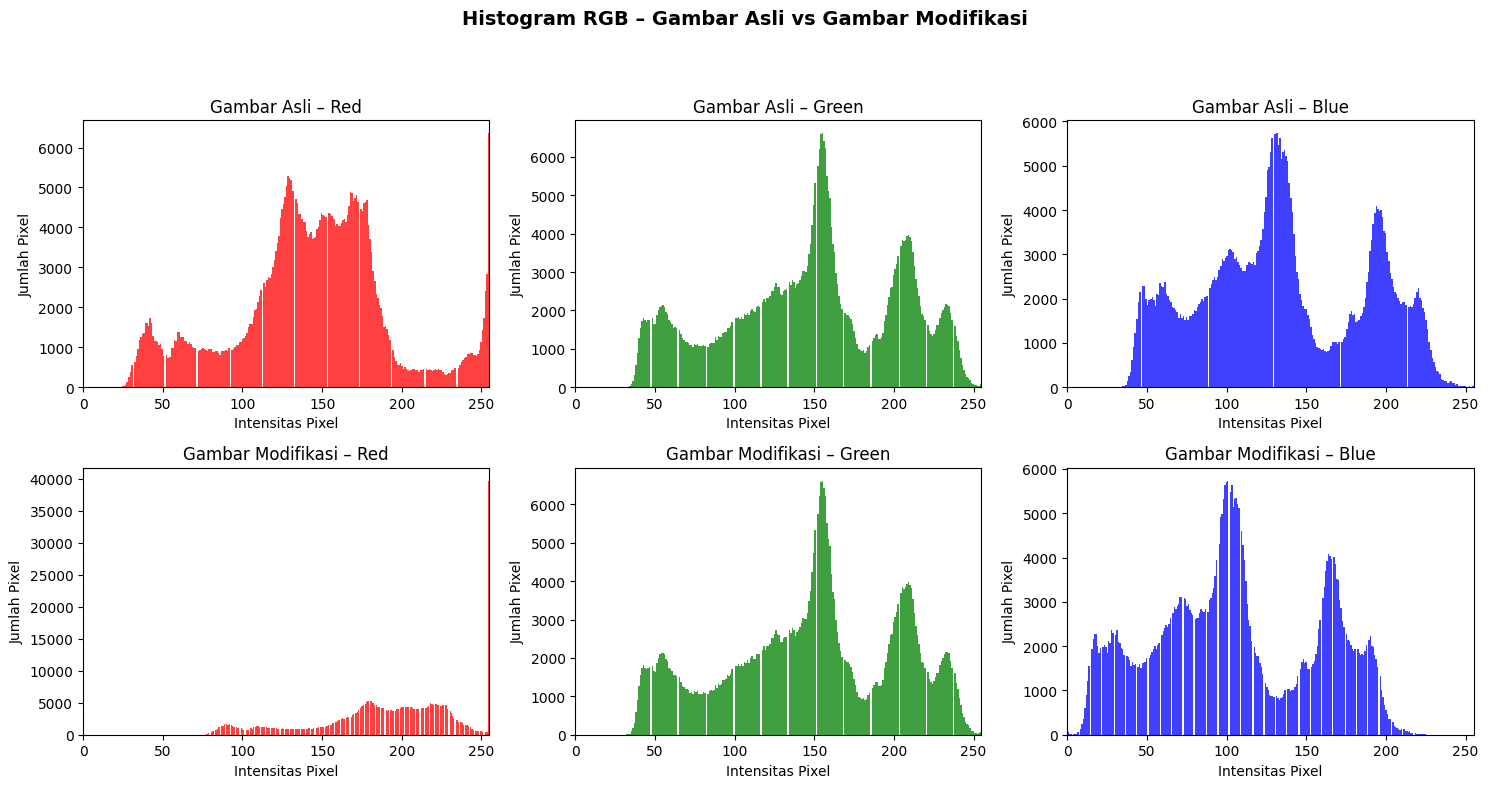

In [78]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Lokasi file
path_face = os.path.join(os.getcwd(), "results_ws4", "Soal1_crop_face.jpg")
path_modif = os.path.join(os.getcwd(), "results_ws4", "Soal2_gabungan_warna.png")

# Baca gambar asli & modifikasi
img_asli_bgr = cv2.imread(path_face)
img_modif_bgr = cv2.imread(path_modif)

# Konversi ke RGB
img_asli = cv2.cvtColor(img_asli_bgr, cv2.COLOR_BGR2RGB)
img_modif = cv2.cvtColor(img_modif_bgr, cv2.COLOR_BGR2RGB)

# Setup layout figure
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Nama dan warna channel
nama_channel = ["Red", "Green", "Blue"]
warna_channel = ["r", "g", "b"]

# Histogram untuk gambar asli
for i in range(3):
    ax = axes[0, i]
    data = img_asli[:, :, i].ravel()
    ax.hist(data, bins=256, color=warna_channel[i], alpha=0.75)
    ax.set_title(f"Gambar Asli – {nama_channel[i]}")
    ax.set_xlim(0, 255)
    ax.set_xlabel("Intensitas Pixel")
    ax.set_ylabel("Jumlah Pixel")

# Histogram untuk gambar modifikasi
for i in range(3):
    ax = axes[1, i]
    data = img_modif[:, :, i].ravel()
    ax.hist(data, bins=256, color=warna_channel[i], alpha=0.75)
    ax.set_title(f"Gambar Modifikasi – {nama_channel[i]}")
    ax.set_xlim(0, 255)
    ax.set_xlabel("Intensitas Pixel")
    ax.set_ylabel("Jumlah Pixel")

# Judul besar
plt.suptitle("Histogram RGB – Gambar Asli vs Gambar Modifikasi", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


#### **Menjelaskan dampak perubahan RGB pada warna gambar**
Melakukan perubahan pada sebuah intensitas warna pada channel RGB membuat perubahan warna pada gambar. ketika intensitas warna merah dinaikkan sebanyak +50 terlihat foto menjadi warna kemerahan yang disebabkan kenaikkkan intensitas warna merah. sedangkan untuk warna biru dilakukan penurunan intensitas sebanyak -30 hal tersebut membuat warna biru menjadi lebih pudar atau gelap. perubahan pada intensitas warna tersebut mempengaruhi keseluruhan warna pada gambar sehingga menghasilkan warna yang berbeda dari gambar aslinya.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


#### **Soal 3 — Langkah-Langkah Jawaban**
1. Menampilkan gambar dan objek dengan background bertekstur.

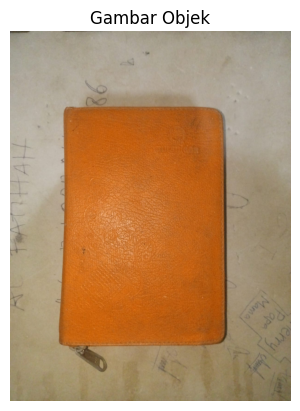

In [317]:
# Path gambar
path_gambar = os.path.join(os.getcwd(), "assets_ws4", "objek.jpg")

# Baca file gambar
img_bgr = cv2.imread(path_gambar)

# Pastikan gambar terbaca
if img_bgr is None:
    print("Gambar tidak ditemukan:", path_gambar)
else:
    # Konversi ke RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Tampilkan gambar
    plt.imshow(img_rgb)
    plt.title("Gambar Objek")
    plt.axis("off")
    plt.show()

2. Menerapkan edge detection (Canny) dan mengatur thresholding lalu menampilkan hasilnya.

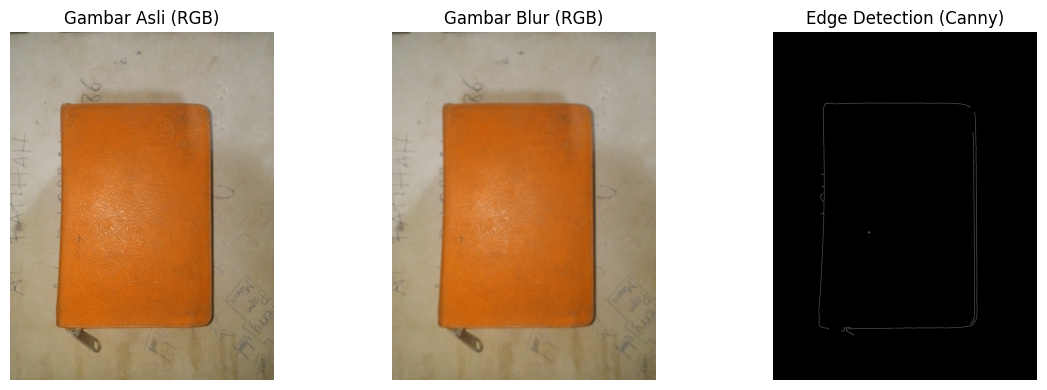

True

In [195]:
# Membaca gambar
img_bgr = cv2.imread(path_gambar)

# Konversi BGR ke RGB
rgb_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Membuat gambar blur
blur_img = cv2.GaussianBlur(rgb_img, (15, 15), 0)

# Edge detection (Canny)
edges = cv2.Canny(blur_img, 100, 40)

# Tampilkan hasil (asli, blur, edge)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_img)
plt.title("Gambar Asli (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_img)
plt.title("Gambar Blur (RGB)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Edge Detection (Canny)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Menyimpan hasil blur
output_dir = os.path.join(os.getcwd(), "results_ws4")
os.makedirs(output_dir, exist_ok=True)
cv2.imwrite(os.path.join(output_dir, "Soal3_blur_image.png"), cv2.cvtColor(blur_img, cv2.COLOR_RGB2BGR))
# Menyimpan hasil edge detection
output_dir = os.path.join(os.getcwd(), "results_ws4")
os.makedirs(output_dir, exist_ok=True)
cv2.imwrite(os.path.join(output_dir, "Soal3_edge_detection.png"), edges)


3. Membuat bounding box di sekitar objek hasil segmentasi.

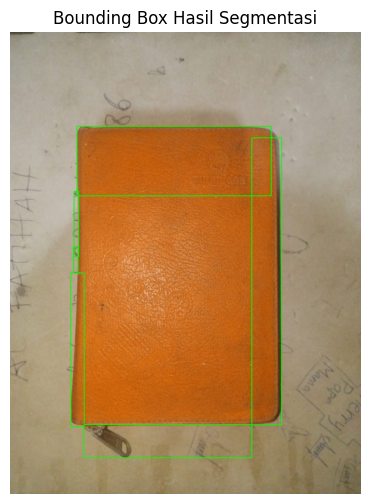

True

In [314]:
# Path gambar asli
path_gambar = os.path.join(os.getcwd(), "assets_ws4", "objek.jpg")

# Baca gambar
img_bgr = cv2.imread(path_gambar)
rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Blur + Canny (segmentasi tepi)
blur_img = cv2.GaussianBlur(rgb, (13, 13), 0)
edges = cv2.Canny(blur_img, 135, 20)

# Temukan kontur dari hasil edge detection
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copy gambar asli untuk digambar bounding box
bbox_img = img_bgr.copy()

# Gambar bounding box untuk setiap objek
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(bbox_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Konversi BGR ke RGB
bbox_rgb = cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB)

# Hasil
plt.figure(figsize=(8, 6))
plt.imshow(bbox_rgb)
plt.title("Bounding Box Hasil Segmentasi")
plt.axis("off")
plt.show()

# Menyimpan hasil dengan bounding box
output_dir = os.path.join(os.getcwd(), "results_ws4")
os.makedirs(output_dir, exist_ok=True)
cv2.imwrite(os.path.join(output_dir, "Soal3_bounding_box.png"), bbox_img)


4. Menerapkan filter blur dan filter sharpening, lalu menampilkan hasil keduanya.

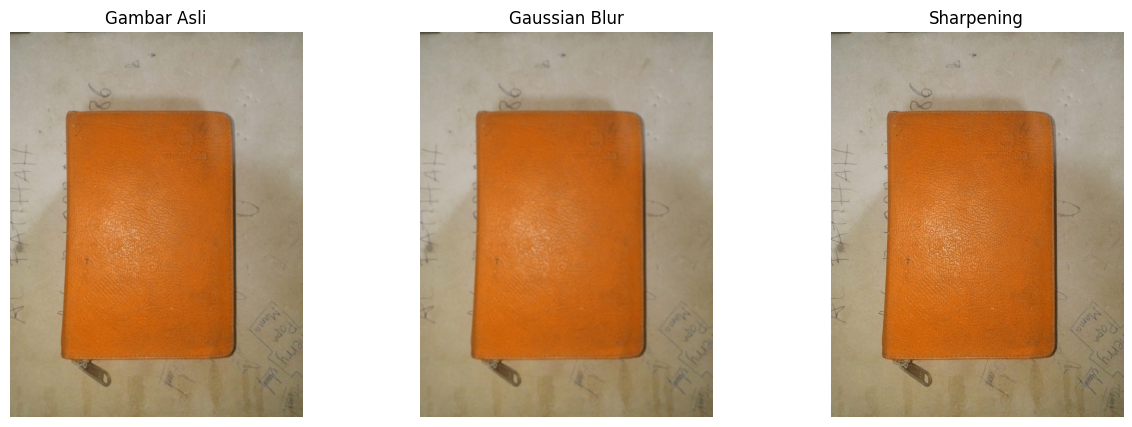

In [316]:
# Path gambar
img_path = os.path.join(os.getcwd(), "assets_ws4", "objek.jpg")

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Filter Gaussian Blur
blur = cv2.GaussianBlur(img_rgb, (11, 11), 0)

# Filter Sharpening
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])
sharpen = cv2.filter2D(img_rgb, -1, kernel_sharpen)

# Menampilkan hasil
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpen)
plt.title("Sharpening")
plt.axis("off")

plt.show()

#### **Menjelaskan bagaimana setiap filter memengaruhi detail gambar**
1. **Filter Blur (Gaussian Blur)**

    Pada filter blur (Gaussian Blur) membuat gambar menjadi lebih halus dan mengurangi noise atau detail-detail yang terlalu kecil pada gambar. Hal ini berguna untuk menghilangkan gangguan visual dan membuat objek utama lebih menonjol.

2. **Filter Sharpening**

    Filter sharpening meningkatkan kontras tepi pada gambar, sehingga detail-detail pada gambar menjadi lebih tajam dan jelas. Hal ini berguna untuk menonjolkan fitur-fitur penting pada gambar, namun dapat juga memperkuat noise jika tidak digunakan dengan hati-hati.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

#### **Soal 4 — Langkah-Langkah Jawaban**
1. Melakukan deteksi wajah dengan Dlib.

Jumlah wajah yang ditemukan dlib: 1
 - Wajah 1: posisi (344,582), ukuran 536 x 536


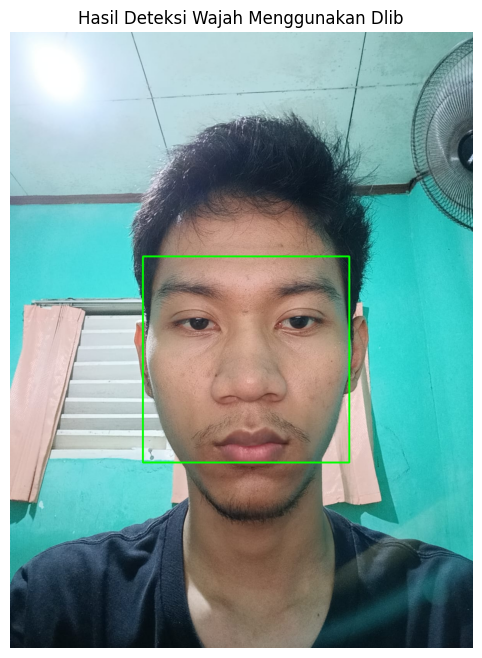

✔ Gambar hasil deteksi berhasil disimpan ke: c:\Users\okedi\OneDrive\Documents\Multimedia\Worksheet 4\results_ws4\Dlib_Face_Detection_Result.jpg


In [320]:
# Lokasi gambar menggunakan os.path.join
gambar_path = os.path.join(os.getcwd(), "assets_ws4", "selfie_natural.jpg")

# Membaca gambar dan menyiapkan versi grayscale untuk dlib
gambar_bgr = cv2.imread(gambar_path)
gambar_rgb = cv2.cvtColor(gambar_bgr, cv2.COLOR_BGR2RGB)
abu = cv2.cvtColor(gambar_bgr, cv2.COLOR_BGR2GRAY)

# Membuat detector wajah dari dlib
face_detector = dlib.get_frontal_face_detector()

# Mendeteksi lokasi wajah pada gambar
hasil_deteksi = face_detector(abu)

print(f"Jumlah wajah yang ditemukan dlib: {len(hasil_deteksi)}")

# Duplikasi gambar untuk menggambar kotak
gambar_dlib = gambar_bgr.copy()

# Menggambar bounding box dan menambahkan label
for nomor, area in enumerate(hasil_deteksi, start=1):
    kiri = area.left()
    atas = area.top()
    kanan = area.right()
    bawah = area.bottom()

    # Menggambar kotak deteksi
    cv2.rectangle(
        gambar_dlib, 
        (kiri, atas), 
        (kanan, bawah), 
        (0, 255, 0), 4
    )

    # Menampilkan detail ke console
    lebar = area.width()
    tinggi = area.height()
    print(f" - Wajah {nomor}: posisi ({kiri},{atas}), ukuran {lebar} x {tinggi}")

# Menampilkan hasil deteksi
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(gambar_dlib, cv2.COLOR_BGR2RGB))
plt.title("Hasil Deteksi Wajah Menggunakan Dlib")
plt.axis("off")
plt.show()

# Menyimpan hasil akhir
output_dir = os.path.join(os.getcwd(), "results_ws4")
os.makedirs(output_dir, exist_ok=True)

hasil_simpan = os.path.join(output_dir, "Dlib_Face_Detection_Result.jpg")
cv2.imwrite(hasil_simpan, gambar_dlib)

2. Melakukan deteksi landmark wajah.

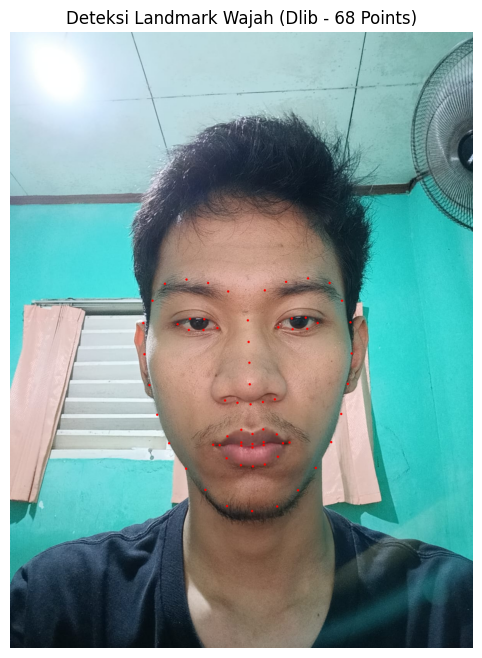

True

In [329]:
# Lokasi file model
model_file = os.path.join(os.getcwd(), "shape_predictor_68_face_landmarks.dat")

# Jika model belum tersedia, download otomatis
if not os.path.isfile(model_file):
    print("Model belum ditemukan, mengunduh file model (sekitar 100MB)...")
    source_url = "https://github.com/italojs/facial-landmarks-recognition/raw/master/shape_predictor_68_face_landmarks.dat"
    urllib.request.urlretrieve(source_url, model_file)
    print("Model berhasil diunduh.")

# Inisialisasi detector dan predictor dlib
face_detector = dlib.get_frontal_face_detector()
landmark_model = dlib.shape_predictor(model_file)

# Memuat gambar asli
img_path = os.path.join(os.getcwd(), "assets_ws4", "selfie_natural.jpg")
original_img = cv2.imread(img_path)

# Mengubah ke grayscale untuk deteksi wajah
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

# Deteksi wajah
detected_faces = face_detector(gray_img)

# Salin gambar untuk menggambar landmark
img_with_landmarks = original_img.copy()

# Memproses semua wajah yang ditemukan
for i, face_box in enumerate(detected_faces):
    # Mendapatkan landmark
    points = landmark_model(gray_img, face_box)
    
    # Menandai 68 titik wajah
    for point_id in range(68):
        px = points.part(point_id).x
        py = points.part(point_id).y
        cv2.circle(img_with_landmarks, (px, py), 3, (0, 0, 255), -1)

# Menampilkan hasil
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_landmarks, cv2.COLOR_BGR2RGB))
plt.title("Deteksi Landmark Wajah (Dlib - 68 Points)")
plt.axis("off")
plt.show()

# Menyimpan hasil
save_dir = os.path.join(os.getcwd(), "results_ws4")
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "Soal4_Landmark_Dlib_Output.jpg")
cv2.imwrite(save_path, img_with_landmarks)


3. Membuat filter berdasarkan landmark wajah yang sudah dibuat.

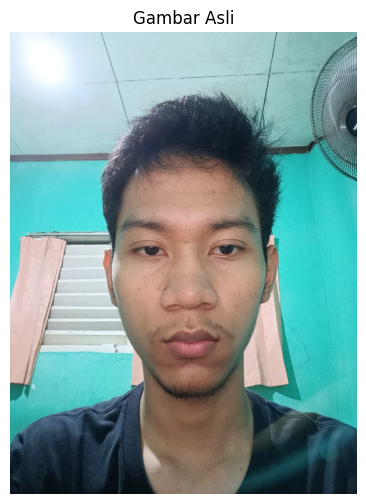

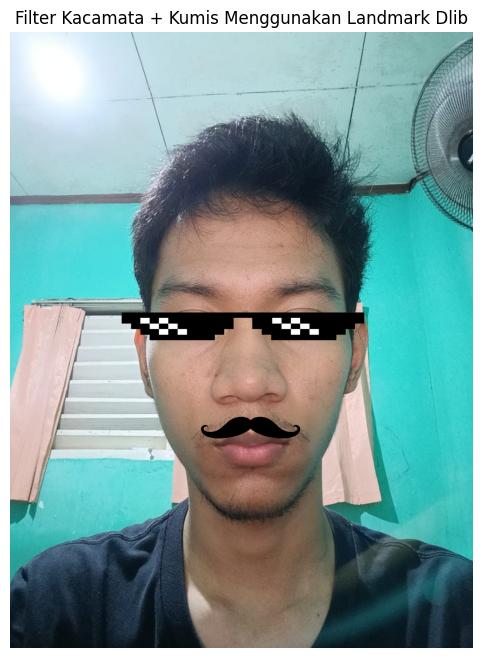

True

In [327]:
# Fungsi untuk menempatkan overlay (kacamata / kumis)
def overlay_image(background, overlay, x, y, w, h):
    overlay_resized = cv2.resize(overlay, (w, h))

    # Jika overlay punya alpha-channel
    if overlay_resized.shape[2] == 4:
        alpha = overlay_resized[:, :, 3] / 255.0
        alpha = alpha[..., np.newaxis]
        overlay_rgb = overlay_resized[:, :, :3]
    else:
        alpha = np.ones((h, w, 1), dtype=float)
        overlay_rgb = overlay_resized

    # Tempelkan ke background
    bg_region = background[y:y+h, x:x+w]
    blended = alpha * overlay_rgb + (1 - alpha) * bg_region
    background[y:y+h, x:x+w] = blended.astype(np.uint8)


# Path file yang digunakan
img_path = os.path.join(os.getcwd(), "assets_ws4", "selfie_natural.jpg")
glasses_path = os.path.join(os.getcwd(), "assets_ws4", "kacamata.png")
mustache_path = os.path.join(os.getcwd(), "assets_ws4", "kumis.png")
model_path = os.path.join(os.getcwd(), "shape_predictor_68_face_landmarks.dat")

# Load gambar dan model
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

glasses_img = cv2.imread(glasses_path, cv2.IMREAD_UNCHANGED)
mustache_img = cv2.imread(mustache_path, cv2.IMREAD_UNCHANGED)

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(model_path)

# Deteksi wajah dan landmark
faces = detector(gray)

for face in faces:
    landmarks = predictor(gray, face)

    # 1. FILTER KACAMATA (berdasarkan mata kiri dan kanan)
    left_eye_x = landmarks.part(36).x
    left_eye_y = landmarks.part(37).y

    right_eye_x = landmarks.part(45).x
    right_eye_y = landmarks.part(44).y

    # Hitung posisi & ukuran kacamata
    eye_width = right_eye_x - left_eye_x
    glasses_width = int(eye_width * 2.0)
    glasses_height = int(glasses_width * 0.4)

    glasses_x = left_eye_x - int(eye_width * 0.5)
    glasses_y = left_eye_y - int(glasses_height * 0.4)

    overlay_image(img, glasses_img, glasses_x, glasses_y, glasses_width, glasses_height)

    # 2. FILTER KUMIS (berdasarkan titik hidung & bibir)
    nose_x = landmarks.part(33).x
    nose_y = landmarks.part(33).y

    mouth_left = landmarks.part(48).x
    mouth_right = landmarks.part(54).x

    mustache_width = int((mouth_right - mouth_left) * 1.3)
    mustache_height = int(mustache_width * 0.4)

    mustache_x = nose_x - mustache_width // 2
    mustache_y = nose_y + 10  # sedikit turun agar pas di atas bibir

    overlay_image(img, mustache_img, mustache_x, mustache_y, mustache_width, mustache_height)

# Tampilkan hasil akhir
plt.figure(figsize=(14, 6))

# Gambar asli
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis("off")

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Filter Kacamata + Kumis Menggunakan Landmark Dlib")
plt.axis("off")
plt.show()

# Simpan hasil
save_dir = os.path.join(os.getcwd(), "results_ws4")
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "Soal4_Filter_Kacamata_Kumis.png")
cv2.imwrite(save_path, img)


#### **Menjelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi**

Perhitungan posisi overlay dilakukan dengan memanfaatkan titik-titik landmark wajah sebagai acuan utama. Jarak antar landmark tertentu seperti jarak antara mata kiri dan mata kanan untuk kacamata, serta lebar mulut untuk kumis digunakan untuk menentukan ukuran overlay agar proporsional dengan wajah. Setelah ukuran ditentukan, program mencari titik pusat berdasarkan landmark yang paling stabil (misalnya titik antara kedua mata atau titik bawah hidung), kemudian overlay digeser setengah dari ukurannya agar posisi PNG berada tepat pada bagian wajah yang diinginkan. Proses ini dilanjutkan dengan alpha blending, yaitu penggabungan piksel overlay dan gambar asli menggunakan nilai transparansi dari PNG agar filter tampak menyatu secara alami.

Tantangan utama dalam implementasi ini adalah menyesuaikan filter dengan berbagai bentuk dan ukuran wajah, memastikan overlay tidak keluar dari batas gambar, serta mengelola alpha channel agar transparansi bekerja dengan benar. Selain itu, wajah yang sedikit miring atau tidak menghadap frontal dapat membuat posisi overlay tampak kurang presisi, karena metode ini belum memperhitungkan rotasi wajah secara penuh.


### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

#### **Soal 5 — Langkah-Langkah Jawaban**
1. Menulis kode untuk memuat gambar dan informasi dasar.

Gambar berhasil dimuat dari: c:\Users\okedi\OneDrive\Documents\Multimedia\Worksheet 4\assets_ws4\objek_datar.jpg


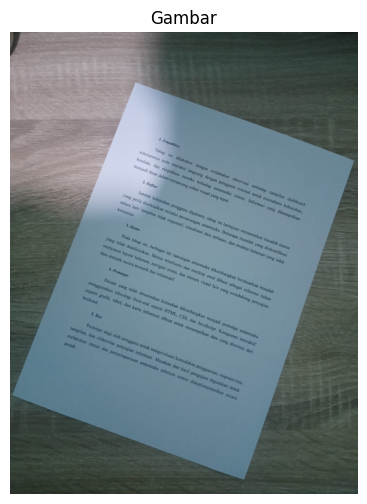

In [452]:
# Path menuju gambar di folder results_ws4
img_path = os.path.join(os.getcwd(), "assets_ws4", "objek_datar.jpg")

# Memuat gambar
img = cv2.imread(img_path)

print("Gambar berhasil dimuat dari:", img_path)

# Menampilkan gambar
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar")
plt.axis("off")
plt.show()


2. Melakukan preprocessing untuk memperbaiki tampilan gambar.

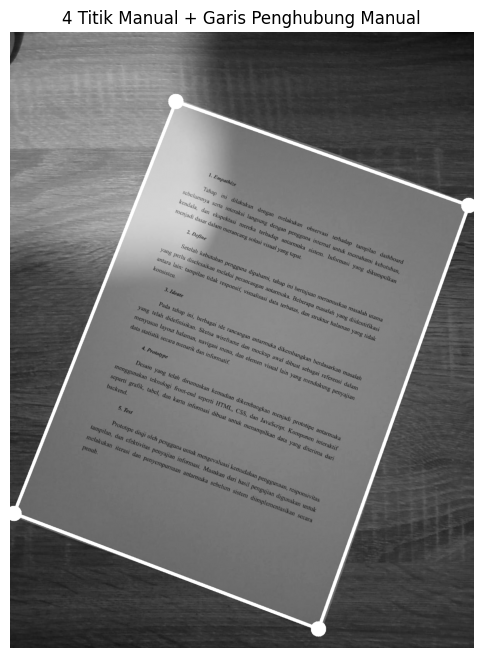

: 

In [ ]:
# Memuat gambar grayscale
img_path = os.path.join(os.getcwd(), "assets_ws4", "objek_datar.jpg")
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Salinan untuk digambar
img_marked = img_gray.copy()

# Titik 4 sudut
manual_pts = [
    (430, 180),    
    (1190, 450),
    (800, 1550),
    (10, 1250)
]

# Konversi ke format array OpenCV
pts_array = np.array(manual_pts, dtype=np.int32).reshape((-1, 1, 2))

# Gambar lingkaran di setiap titik
for (x, y) in manual_pts:
    cv2.circle(img_marked, (x, y), 20, (255, 255, 255), -1)

# Gambar garis (polygon) mengikuti urutan titik
cv2.polylines(img_marked, [pts_array], True, (255, 255, 255), 8)

# Tampilkan hasil
plt.figure(figsize=(7, 8))
plt.imshow(img_marked, cmap='gray')
plt.title("4 Titik Manual + Garis Penghubung Manual")
plt.axis('off')
plt.show()



3. Melakukan koreksi perspektif

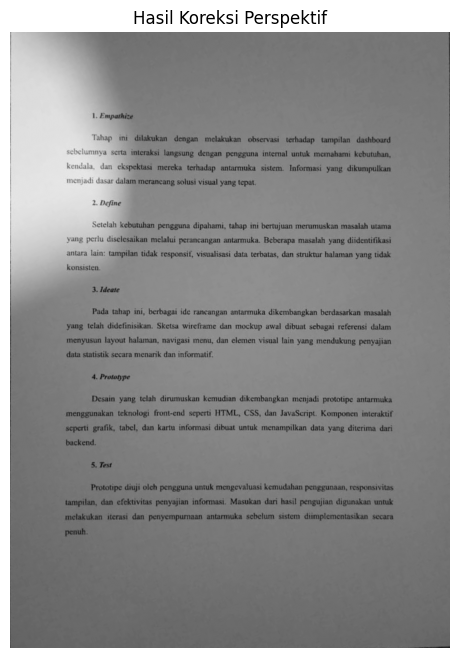

: 

In [ ]:
# Fungsi untuk mengurutkan 4 titik (TL, TR, BL, BR)
def reorder_points(pts):
    pts = np.array(pts, dtype=np.float32)
    ordered = np.zeros((4, 2), dtype=np.float32)

    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1)

    ordered[0] = pts[np.argmin(s)]      # top-left
    ordered[1] = pts[np.argmin(d)]      # top-right
    ordered[2] = pts[np.argmax(d)]      # bottom-left
    ordered[3] = pts[np.argmax(s)]      # bottom-right

    return ordered

# Urutkan titik
src_pts = reorder_points(manual_pts)

# Ukuran output
w, h = 1000, 1400

dst_pts = np.float32([
    [0, 0],
    [w-1, 0],
    [0, h-1],
    [w-1, h-1]
])

# Matriks transformasi
M = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped = cv2.warpPerspective(gray, M, (w, h))

plt.figure(figsize=(7, 8))
plt.imshow(warped, cmap="gray")
plt.title("Hasil Koreksi Perspektif")
plt.axis("off")
plt.show()


4. Melakukan adaptive thresholding

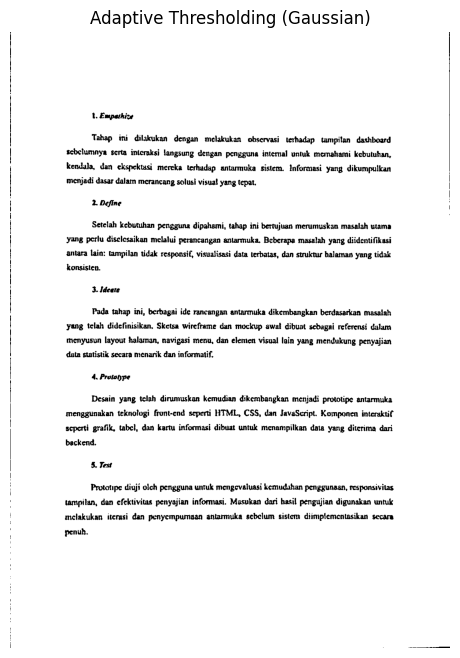

: 

In [ ]:
thresh = cv2.adaptiveThreshold(
    warped, 
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    41,
    8
)

plt.figure(figsize=(7, 8))
plt.imshow(thresh, cmap="gray")
plt.title("Adaptive Thresholding (Gaussian)")
plt.axis("off")
plt.show()


5. menampilkan setiap tahap pemrosesan dalam satu grid agar mudah dibandingkan.

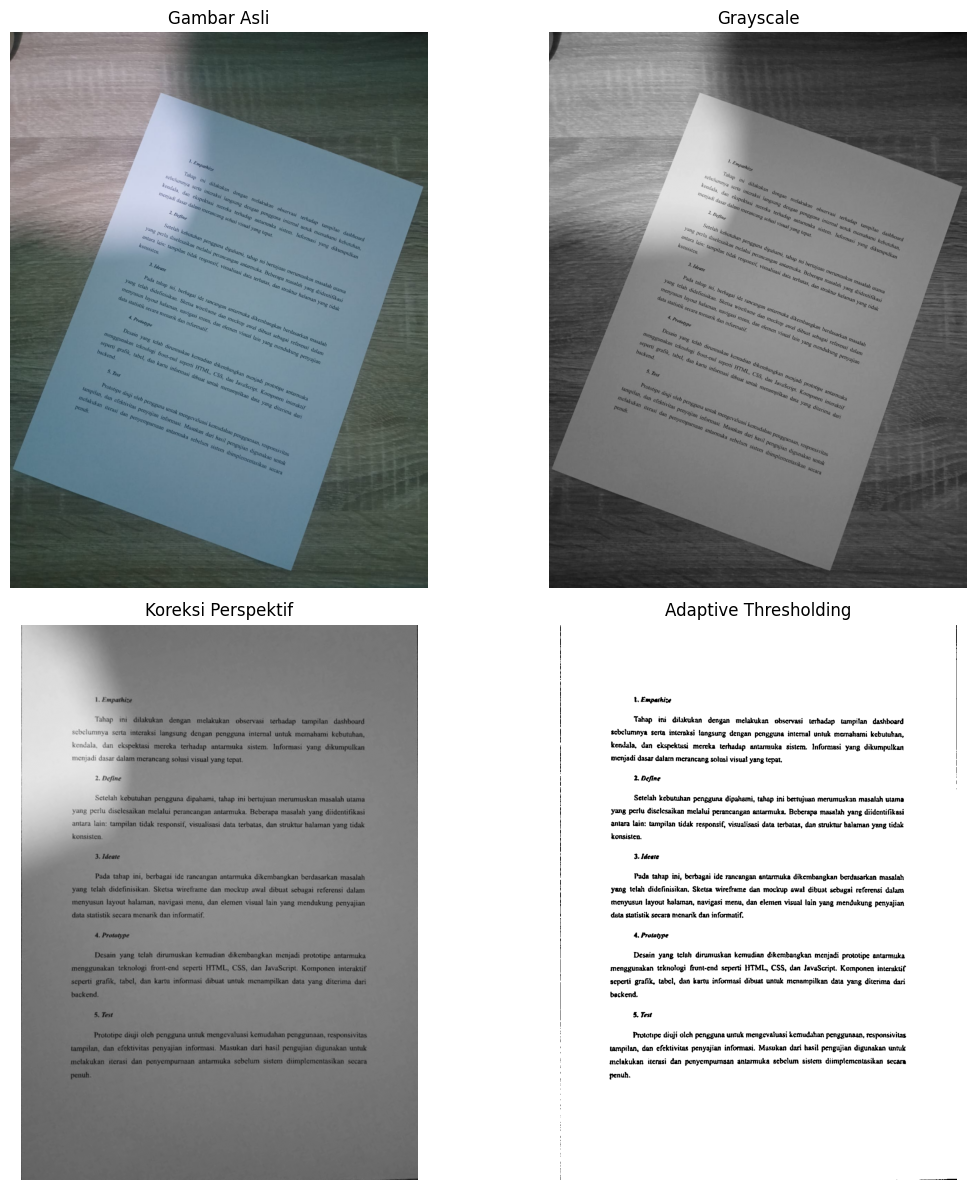

: 

In [ ]:
plt.figure(figsize=(12, 12))

# Gambar Asli
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis("off")

# Grayscale
plt.subplot(2, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

# Hasil Koreksi Perspektif
plt.subplot(2, 2, 3)
if len(warped.shape) == 3:
    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
else:
    plt.imshow(warped, cmap='gray')
plt.title("Koreksi Perspektif")
plt.axis("off")

# Adaptive Threshold
plt.subplot(2, 2, 4)
plt.imshow(thresh, cmap='gray')
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()


#### **Menjelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra**
1. **Konversi ke Grayscale**

    Konversi gambar ke grayscale menghilangkan informasi warna yang tidak diperlukan, sehingga memudahkan proses analisis selanjutnya. Dengan hanya mempertahankan intensitas cahaya, fokus dapat diarahkan pada struktur dan kontur objek.

2. **Koreksi Perspektif**

    Koreksi perspektif menggunakan transformasi homografi memungkinkan kita untuk mengubah sudut pandang gambar sehingga objek datar terlihat sejajar dan tidak terdistorsi. Hal ini penting untuk memastikan bahwa objek dapat dilihat dengan proporsi yang benar, terutama jika gambar diambil dari sudut yang miring.

3. **Adaptive Thresholding**

    Adaptive thresholding dipakai untuk mengatasi pecahayaan yang kurang bagus atau tidak merata pada gambar. Adaptive thresholding membuat warna hanya menjadi hitam putih sehingga cahaya atau bayangan yang tidak diinginkan dapat dihilangkan, sehingga objek utama menjadi lebih jelas dan mudah dikenali.

## Lampiran 
#### Materi Referensi
1. [Materi 1](https://github.com/informatika-itera/IF25-40305-handson/blob/main/8_image_processing_week1.ipynb)
2. [Materi 2](https://github.com/informatika-itera/IF25-40305-handson/blob/main/9_image_processing_week2.ipynb)

#### Chat GPT
1. [Chat GPT]

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.